In [1]:
import pandas as pd
import seaborn as sns
import os
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics.pairwise import cosine_similarity
from tqdm import tqdm
import matplotlib.patches as mpatches
from utils import *
import matplotlib.colors as mcolors



In [2]:
def visualize(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            
            print(cluster_centers)
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                for a in algorithms:
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().cummin().to_frame().reset_index()
                        print(s_min)
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=axes[0]
                        print(axes[0])

                        # Plot the line plot on the first axis

                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                ax1.set_title('Minimum scaled y per cluster and iteration')
                                ax1.set_xlabel('Iteration')
                                ax1.set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1],cmap="YlGnBu", fmt=".3f",norm=mcolors.LogNorm())
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0],cmap='YlGnBu')

                        
                        # Adjust layout
                        plt.tight_layout()
                        if save:
                            file_name=f'{problem}_{a}_run_{run}.pdf'
                            plt.savefig('figures_clustering_new/{file_name}',bbox_inches=0)
                        # Show the combined plot
                        plt.show()
                        
                        '''plt.figure()
                        sns.lineplot(s,x='iteration',y='scaled_raw_y', hue='cluster',palette='tab10')
                        plt.show()
                        
                        plt.figure(figsize=(5,dimension*2))
                        sns.heatmap(df.loc[a,run].T,annot=True)
                        plt.show()'''

In [3]:
def visualize_multi(dimensions, problems, algorithms, runs, line_plot_y=False, plot_y=False, data_dir=None, save=False, popsize=50):
    if data_dir is None:
        data_dir=f'data/clustering_features_x_only'
    for dimension in dimensions:
        directory=f'{data_dir}/cluster_distributions/dim_{dimension}'
        for problem in problems:
            cluster_centers=pd.read_csv(f'{data_dir}/cluster_centers/dim_{dimension}/{problem}.csv',index_col=0)
            print(cluster_centers)
            cluster_count=cluster_centers.shape[0]
            cluster_centers = {index: ', '.join([ str(round(row[c],2)) for c in row.keys()]) for index, row in cluster_centers.iterrows()}
            print(cluster_centers)
            solutions=pd.read_parquet(f'{data_dir}/clustering_results/dim_{dimension}/{problem}.parquet')
            file_loc=f'{directory}/{problem}.csv'
            if os.path.isfile(file_loc):
                df=pd.read_csv(file_loc,index_col=[0,1,2])
                df.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in df.columns]
                fig, all_axes = plt.subplots(len(algorithms), 2 if plot_y else 1, figsize=(cluster_count if plot_y else 10, 3*dimension * len(algorithms)), squeeze=False, sharex=True)
                for a_index, a in enumerate(algorithms):
                    for run in runs:
                        print(problem,a,run)

                        s = solutions.query('algorithm==@a and run==@run').groupby(['iteration', 'cluster'])['scaled_raw_y']
                        s_min=s.min().to_frame().reset_index()
                        #s_mean=s.mean().to_frame().reset_index()
                        #s_stats = pd.concat([s_min.assign(stat='min'), s_mean.assign(stat='mean')])
                        
                        # Create a figure with subplots
                        #fig, axes = plt.subplots(1, 2 if plot_y else 1, figsize=(15 if plot_y else 7, int(s_min['iteration'].max() / 3 )), squeeze=False)
                        axes=all_axes[a_index]

                        # Plot the line plot on the first axis
                        axes[0].set_title(f'Algorithm: {a}; Run: {run}')
                        if plot_y:
                            if line_plot_y:
                                sns.lineplot(data=s_min, x='iteration', y='scaled_raw_y', hue='cluster', style='cluster',palette='tab10',markers=True, dashes=False, ax=axes[1])
                                axes[1].set_title('Minimum scaled y per cluster and iteration')
                                axes[1].set_xlabel('Iteration')
                                axes[1].set_ylabel('Scaled Raw Y')
                            else:
                                s_min_pivoted=s_min.pivot(index='iteration', columns='cluster', values='scaled_raw_y')
                                s_min_pivoted.columns=[f'{int(c)} (Center: {cluster_centers[int(c)]})' for c in s_min_pivoted.columns]
                                sns.heatmap(s_min_pivoted, annot=True,ax=axes[1], vmin=0, vmax=1)
                        
                        # Plot the heatmap on the second axis
                        sns.heatmap(df.loc[a, run].replace(0,np.nan), annot=True, ax=axes[0], vmin=0, vmax=popsize,cmap='YlGnBu')

                        
                        # Adjust layout
                
                plt.tight_layout()
                plt.margins(0, tight=True)
                if save:
                    file_name=f"{data_dir.split('/')[-1]}_{problem}_{'+'.join(algorithms)}_run_{'+'.join([str(r) for r in runs])}.pdf"
                    plt.savefig(f'figures_clustering_new/{file_name}',bbox_inches='tight', pad_inches=0)
                # Show the combined plot
                plt.show()

    scaled_x0  scaled_x1
0   -0.767421  -1.602854
1    1.146708   1.732604
2   -3.014153  -4.176706
3   -0.957608  -0.943126
4    0.534195  -1.086480
..        ...        ...
59  -0.464146  -0.368704
60  -4.086537   0.355019
61   4.281417   2.718164
62  -1.473760   3.713243
63   2.252299   4.498055

[64 rows x 2 columns]
{0: '-0.77, -1.6', 1: '1.15, 1.73', 2: '-3.01, -4.18', 3: '-0.96, -0.94', 4: '0.53, -1.09', 5: '-3.79, -0.99', 6: '2.14, 0.82', 7: '-3.11, -1.6', 8: '-0.87, -1.27', 9: '3.74, -3.45', 10: '4.63, 1.4', 11: '-1.45, -2.48', 12: '-2.29, 1.41', 13: '-1.7, -0.9', 14: '-4.87, -2.93', 15: '0.43, -0.22', 16: '4.43, -1.53', 17: '-4.59, -3.82', 18: '-0.23, -2.79', 19: '2.02, -1.13', 20: '0.73, 3.43', 21: '2.95, 3.33', 22: '-1.48, -4.67', 23: '-1.81, -0.09', 24: '0.65, 0.63', 25: '0.12, -1.63', 26: '-2.39, -2.36', 27: '-0.5, 1.95', 28: '0.53, -4.39', 29: '-1.02, -0.62', 30: '-0.03, -0.92', 31: '-1.87, -3.23', 32: '-1.14, -1.67', 33: '-1.25, -1.13', 34: '-3.99, -2.26', 35: '-2.35, -

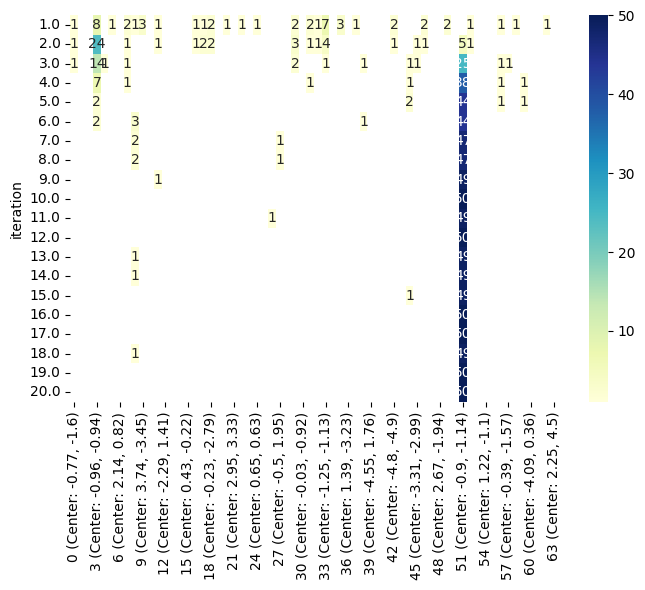

F14_I1 AugmentedAEO 2
     iteration  cluster  scaled_raw_y
0          1.0        0  6.476375e-04
1          1.0        2  6.476375e-04
2          1.0        3  3.051736e-04
3          1.0       14  3.051736e-04
4          1.0       19  3.051736e-04
..         ...      ...           ...
98        19.0       51  6.235058e-08
99        19.0       57  6.235058e-08
100       20.0        8  6.172569e-08
101       20.0       51  6.172569e-08
102       20.0       57  6.172569e-08

[103 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


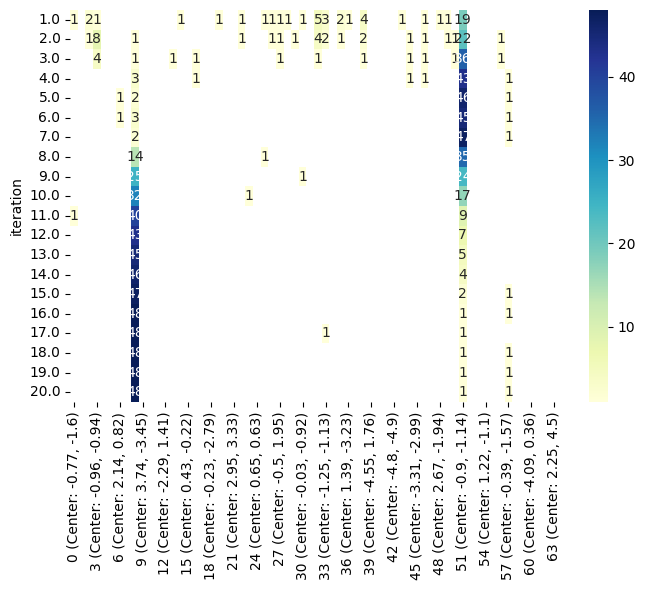

F14_I1 AugmentedAEO 3
     iteration  cluster  scaled_raw_y
0          1.0        0  6.023199e-04
1          1.0        7  6.023199e-04
2          1.0        9  6.023199e-04
3          1.0       10  6.023199e-04
4          1.0       11  6.023199e-04
..         ...      ...           ...
126       18.0       44  1.698207e-07
127       19.0        8  1.693022e-07
128       19.0       44  1.693022e-07
129       20.0        8  1.691630e-07
130       20.0       44  1.691630e-07

[131 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


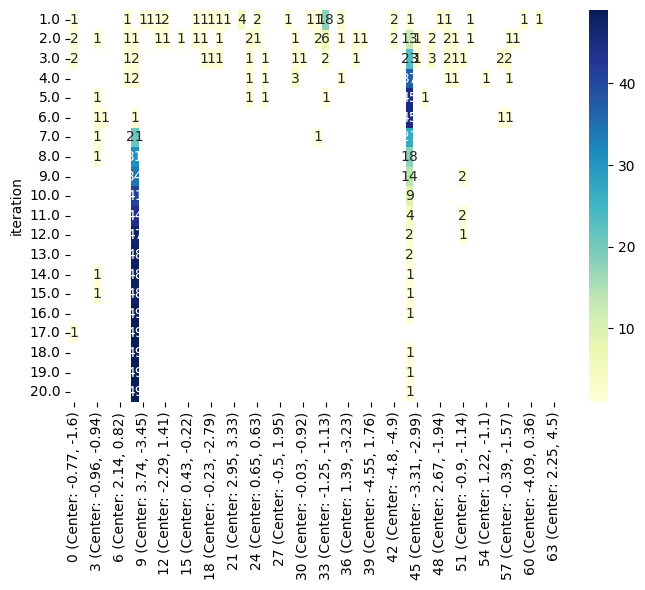

F14_I1 AugmentedAEO 4
     iteration  cluster  scaled_raw_y
0          1.0        3  1.588869e-04
1          1.0        7  1.588869e-04
2          1.0        8  1.588869e-04
3          1.0       10  1.588869e-04
4          1.0       11  1.588869e-04
..         ...      ...           ...
105       16.0        8  2.324225e-08
106       17.0        8  2.324179e-08
107       18.0        8  2.324176e-08
108       19.0        8  2.324141e-08
109       20.0        8  2.324138e-08

[110 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


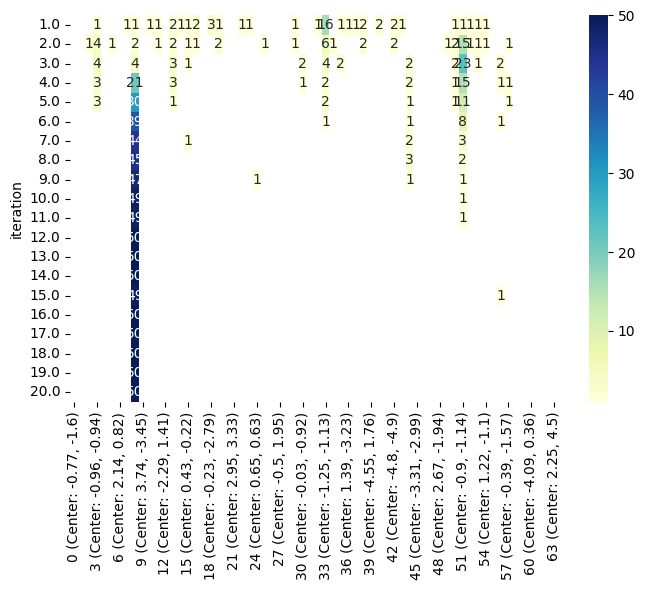

F14_I1 AugmentedAEO 5
     iteration  cluster  scaled_raw_y
0          1.0        0  5.249949e-04
1          1.0        2  5.249949e-04
2          1.0        3  2.893671e-04
3          1.0        4  2.893671e-04
4          1.0        7  2.893671e-04
..         ...      ...           ...
120       18.0       51  1.620441e-07
121       19.0        8  1.612113e-07
122       19.0       51  1.612113e-07
123       20.0        8  1.587260e-07
124       20.0       51  1.587260e-07

[125 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


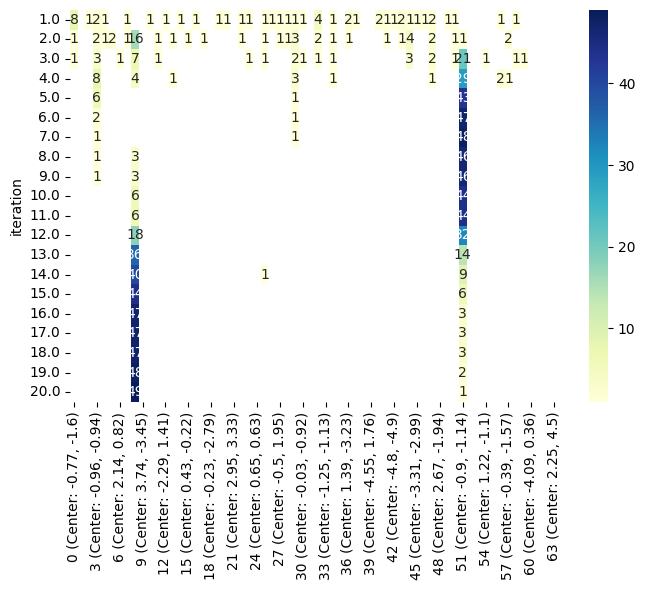

F14_I1 OriginalDE 1
     iteration  cluster  scaled_raw_y
0          1.0        0      0.000187
1          1.0        1      0.000187
2          1.0        2      0.000187
3          1.0        3      0.000187
4          1.0        4      0.000187
..         ...      ...           ...
137       16.0       44      0.000015
138       17.0       44      0.000015
139       18.0       44      0.000014
140       19.0       44      0.000014
141       20.0       44      0.000014

[142 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


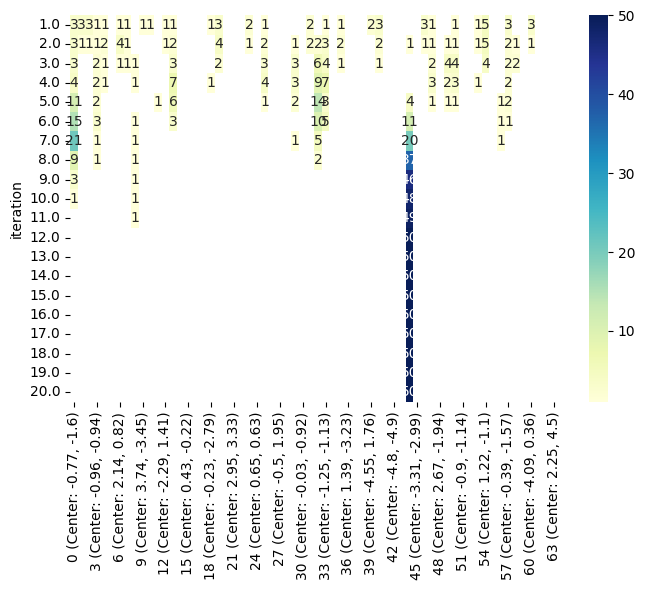

F14_I1 OriginalDE 2
     iteration  cluster  scaled_raw_y
0          1.0        1  2.273091e-02
1          1.0        2  2.273091e-02
2          1.0        6  1.500297e-02
3          1.0        9  1.500297e-02
4          1.0       10  1.500297e-02
..         ...      ...           ...
132       16.0       51  8.987072e-07
133       17.0       51  8.925842e-07
134       18.0       51  8.440299e-07
135       19.0       51  8.440299e-07
136       20.0       51  8.421983e-07

[137 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


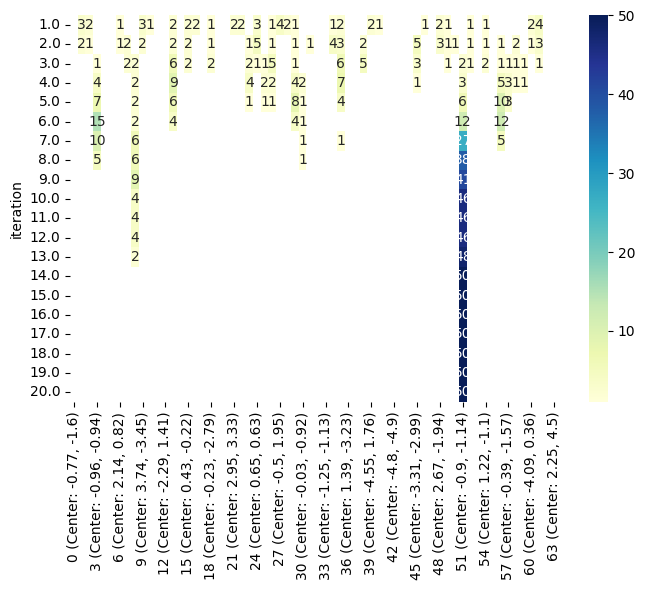

F14_I1 OriginalDE 3
     iteration  cluster  scaled_raw_y
0          1.0        1  2.230593e-02
1          1.0        4  5.603224e-03
2          1.0        5  5.603224e-03
3          1.0        6  5.603224e-03
4          1.0        9  5.603224e-03
..         ...      ...           ...
150       17.0       51  1.323782e-07
151       18.0        8  3.605517e-08
152       18.0       51  3.605517e-08
153       19.0        8  2.082942e-08
154       20.0        8  1.154152e-08

[155 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


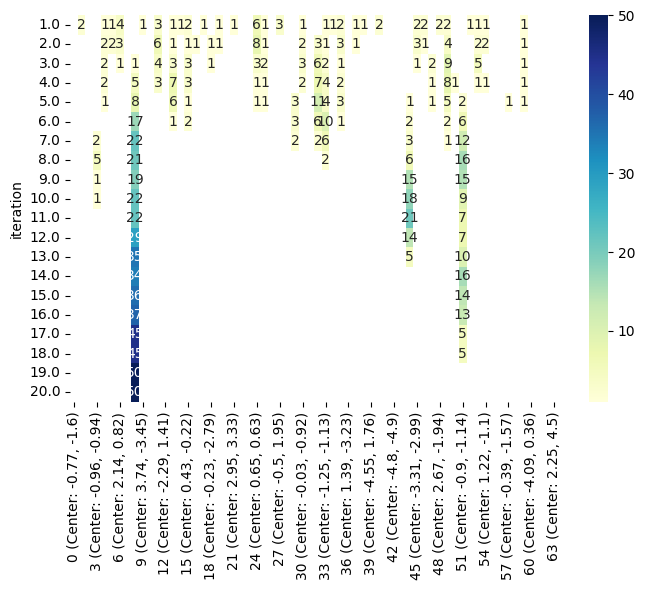

F14_I1 OriginalDE 4
     iteration  cluster  scaled_raw_y
0          1.0        2  7.171015e-02
1          1.0        4  4.406346e-03
2          1.0       10  4.406346e-03
3          1.0       11  4.406346e-03
4          1.0       14  4.406346e-03
..         ...      ...           ...
143       16.0       44  1.407937e-07
144       17.0        8  9.261895e-08
145       18.0        8  2.365875e-08
146       19.0        8  2.365875e-08
147       20.0        8  2.365875e-08

[148 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


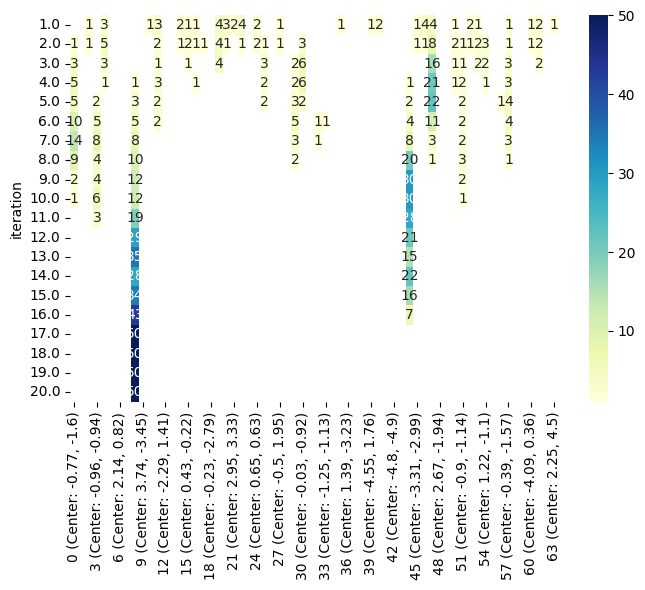

F14_I1 OriginalDE 5
     iteration  cluster  scaled_raw_y
0          1.0        2  2.623835e-02
1          1.0        4  5.788792e-03
2          1.0        6  5.788792e-03
3          1.0        9  5.788792e-03
4          1.0       11  5.788792e-03
..         ...      ...           ...
140       18.0        8  1.180880e-08
141       18.0       51  1.180880e-08
142       19.0        8  8.502715e-09
143       19.0       51  8.502715e-09
144       20.0        8  1.352110e-10

[145 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


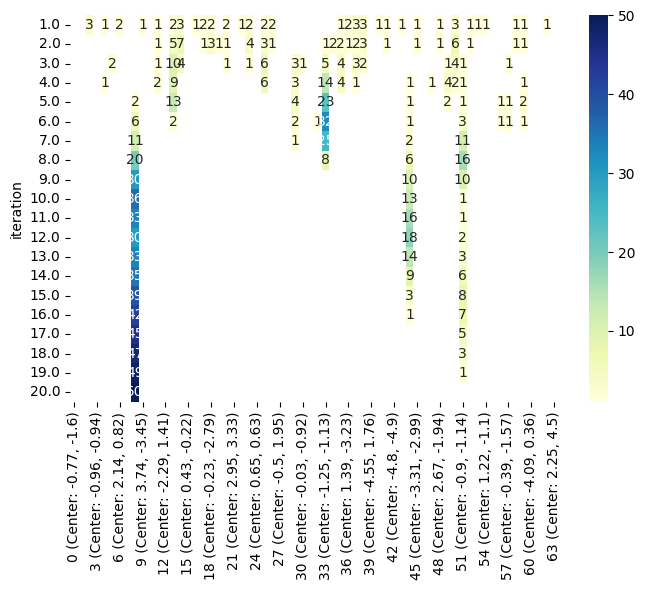

In [4]:
visualize([2], ['F14_I1'], ['AugmentedAEO','OriginalDE'], [1,2,3,4, 5], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', plot_y=False)

In [7]:
algorithms_of_interest=["ModifiedAEO",
"OriginalAEO",
"AugmentedAEO",
"OriginalSHADE",
"SADE",
"JADE",
"OriginalDE",
"OriginalWOA",
"HI_WOA"]

    scaled_x0  scaled_x1
0   -1.329093   1.428670
1   -4.538486  -3.480184
2   -3.782924   0.661374
3    2.279349  -0.159496
4   -2.166210  -0.380001
5    3.155546  -3.991431
6    0.576405   3.107079
7   -3.174017  -4.327252
8    4.569192   0.604639
9   -4.956394  -4.962658
10  -3.067228   0.898775
11  -1.503715   4.413642
12   0.177886  -0.997564
13  -4.290876   0.498781
14  -3.110208  -2.190902
15  -4.493786  -1.159633
16   2.070974   1.945983
17  -0.517095   2.816850
18  -3.450069   3.258853
19  -2.011726  -1.848942
20   3.955556   2.520626
21   0.853538   4.614357
22   1.090820  -3.885356
23   0.562975   1.983316
24  -1.042607  -1.444152
25  -4.881671  -4.488722
26  -4.918133   0.308651
27  -4.464575  -4.555865
28   3.521977   0.226478
29  -2.259128   1.133123
30  -0.347131   1.611885
31  -0.200310   4.110777
{0: '-1.33, 1.43', 1: '-4.54, -3.48', 2: '-3.78, 0.66', 3: '2.28, -0.16', 4: '-2.17, -0.38', 5: '3.16, -3.99', 6: '0.58, 3.11', 7: '-3.17, -4.33', 8: '4.57, 0.6', 9: '-4.96, -

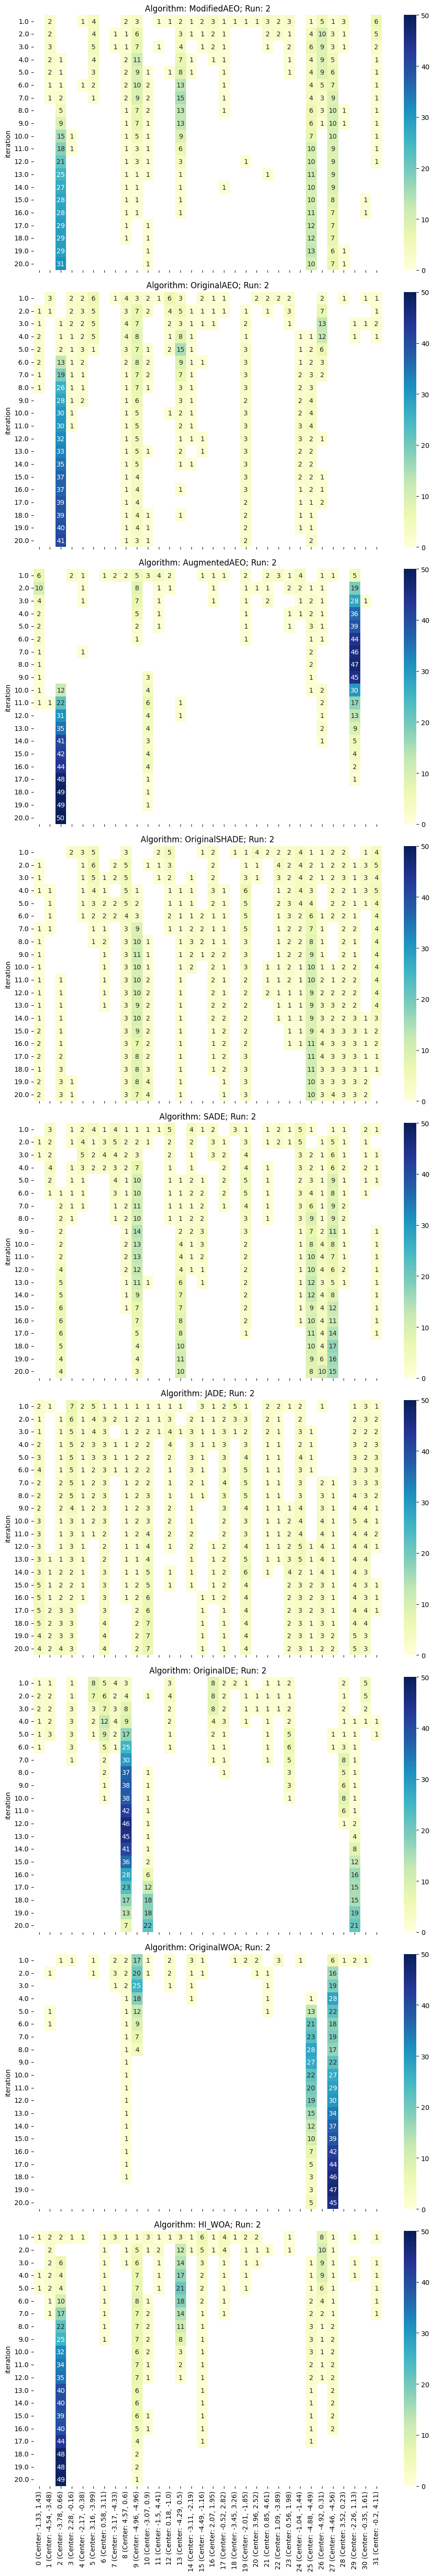

In [8]:
visualize_multi([2], ['F22_I4'], algorithms_of_interest, [2], data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', save=False)

    scaled_x0  scaled_x1
0   -0.445596  -0.404367
1    3.011536  -3.056023
2   -4.931053   3.050077
3   -1.357962   0.332121
4    4.506755  -2.380624
5    1.391076  -1.810996
6   -3.080909   1.639189
7    4.915186  -4.605670
8    3.100037   2.516179
9    0.077661  -0.811051
10  -3.568769   1.973841
11  -3.576658  -0.751524
12   1.887550  -2.238040
13   0.501828   2.794168
14  -0.287935  -2.066894
15   2.445991  -2.624409
16   0.663256  -1.252728
17  -4.516083   4.388947
18  -0.847800  -0.071066
19   3.477221  -0.532852
20  -2.319538   3.876968
21  -2.462211   1.123423
22  -1.027938   2.064640
23   3.932626  -3.787150
24   0.575375  -3.787158
25  -4.421935   0.868499
26  -4.149688   2.467446
27  -1.679716  -1.267266
28  -2.940670  -3.555983
29   0.983282   0.273053
30   2.485225  -4.348003
31  -1.898795   0.715374
{0: '-0.45, -0.4', 1: '3.01, -3.06', 2: '-4.93, 3.05', 3: '-1.36, 0.33', 4: '4.51, -2.38', 5: '1.39, -1.81', 6: '-3.08, 1.64', 7: '4.92, -4.61', 8: '3.1, 2.52', 9: '0.08, -0.8

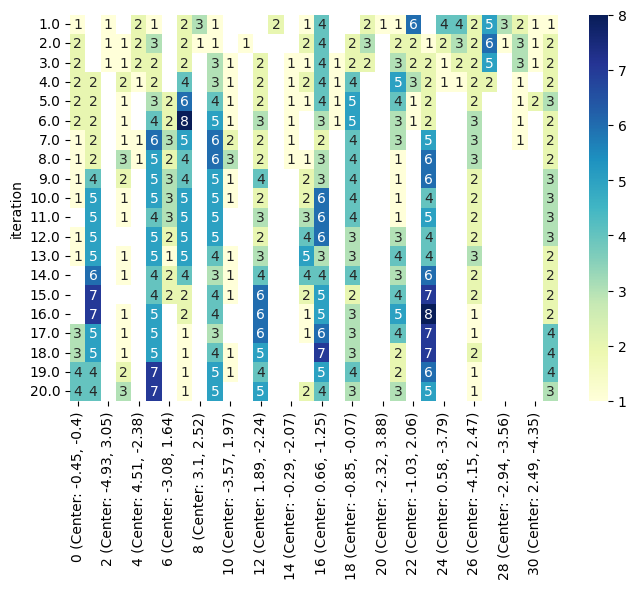

F10_I3 JADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0  8.531847e-04
1          1.0        1  2.375154e-06
2          1.0        3  2.375154e-06
3          1.0        4  2.375154e-06
4          1.0        5  2.375154e-06
..         ...      ...           ...
320       20.0       16  2.580317e-08
321       20.0       18  2.580317e-08
322       20.0       21  2.580317e-08
323       20.0       23  2.580317e-08
324       20.0       31  2.580317e-08

[325 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


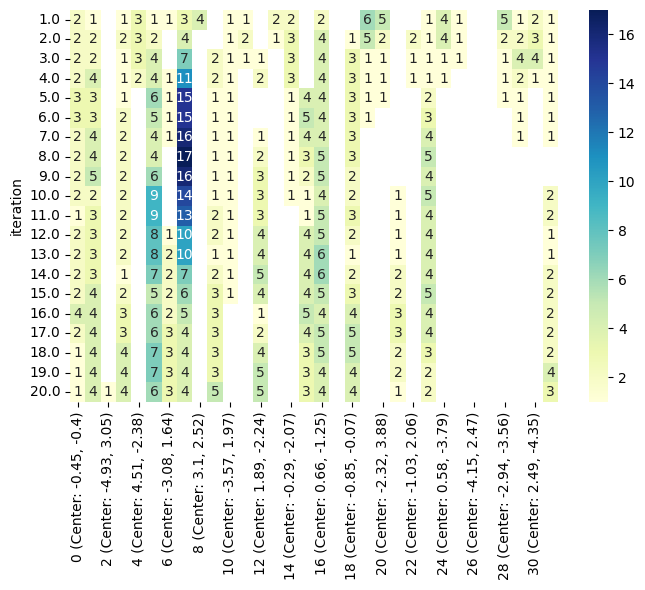

F10_I3 JADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  4.657562e-04
1          1.0        2  4.657562e-04
2          1.0        3  4.657562e-04
3          1.0        4  4.657562e-04
4          1.0        5  4.657562e-04
..         ...      ...           ...
321       20.0       16  4.483165e-08
322       20.0       18  4.483165e-08
323       20.0       21  4.483165e-08
324       20.0       26  4.483165e-08
325       20.0       31  4.483165e-08

[326 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


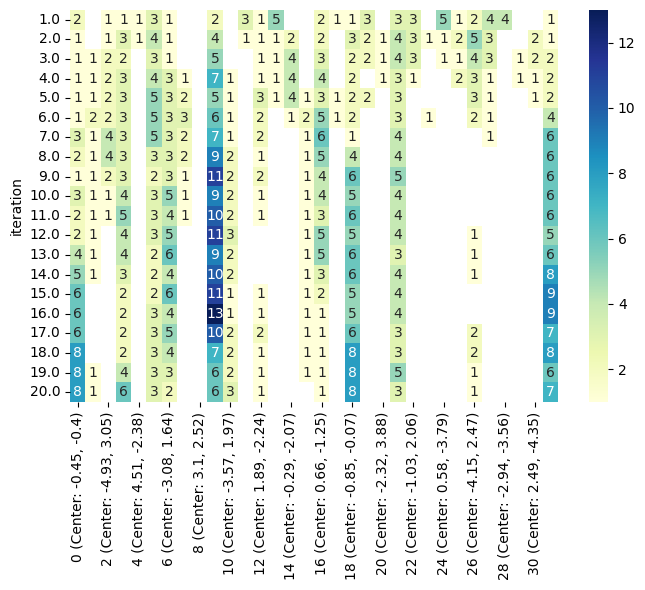

F10_I3 SADE 1
     iteration  cluster  scaled_raw_y
0          1.0        0  3.660987e-03
1          1.0        1  5.271800e-04
2          1.0        3  1.551012e-05
3          1.0        4  1.551012e-05
4          1.0        5  1.551012e-05
..         ...      ...           ...
323       20.0       15  1.107346e-08
324       20.0       16  1.107346e-08
325       20.0       18  1.107346e-08
326       20.0       21  1.107346e-08
327       20.0       31  1.107346e-08

[328 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


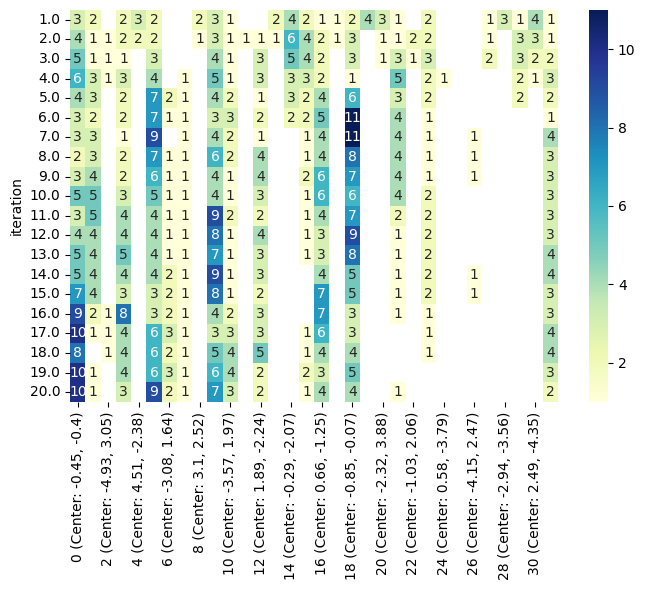

F10_I3 SADE 2
     iteration  cluster  scaled_raw_y
0          1.0        0  5.427041e-04
1          1.0        1  5.427041e-04
2          1.0        2  5.427041e-04
3          1.0        4  5.427041e-04
4          1.0        5  5.153651e-05
..         ...      ...           ...
312       20.0       16  4.871760e-08
313       20.0       18  4.871760e-08
314       20.0       21  4.871760e-08
315       20.0       23  4.871760e-08
316       20.0       31  4.871760e-08

[317 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


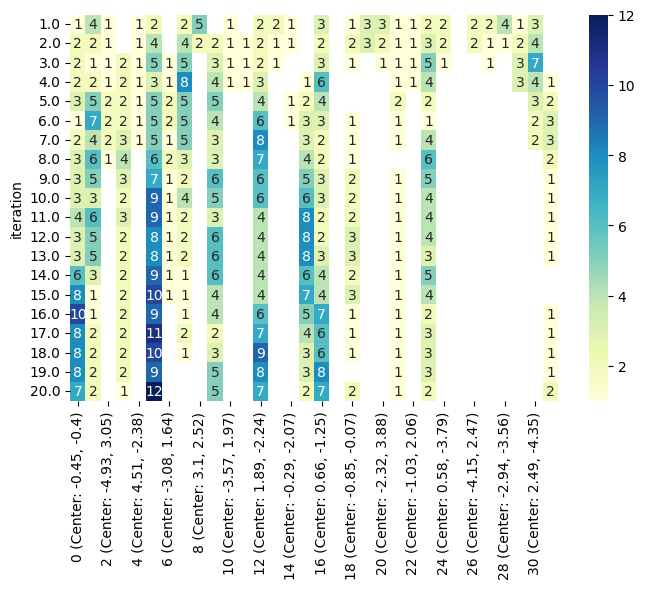

F10_I3 SADE 3
     iteration  cluster  scaled_raw_y
0          1.0        0  3.436563e-04
1          1.0        1  2.352330e-04
2          1.0        2  2.352330e-04
3          1.0        3  6.637174e-07
4          1.0        4  6.637174e-07
..         ...      ...           ...
342       20.0       16  3.465186e-09
343       20.0       18  3.465186e-09
344       20.0       21  3.465186e-09
345       20.0       23  3.465186e-09
346       20.0       31  3.465186e-09

[347 rows x 3 columns]
Axes(0.125,0.11;0.775x0.77)


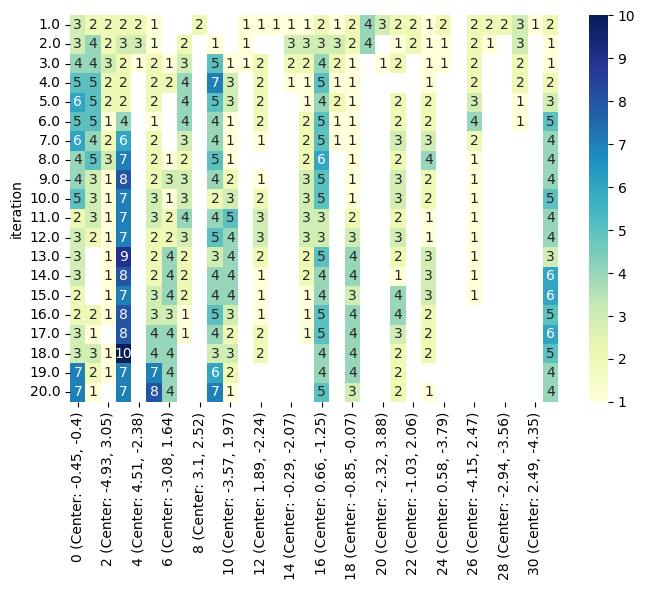

In [10]:
visualize([2], ['F10_I3'], ['JADE','SADE'], [1,2,3],data_dir=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init', plot_y=False)

In [11]:
dimension=2
directory=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init/cluster_distributions/dim_{dimension}'

trajectory_similarities=[]
for file in tqdm(os.listdir(directory)):
    file_loc=f'{directory}/{file}'
    if os.path.isfile(file_loc):
        df=pd.read_csv(file_loc,index_col=[0,1,2])
        d_algorithm_run=df.unstack(level=-1).dropna()
        #d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
        cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
        c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
        trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]

trajectory_similarities=pd.concat(trajectory_similarities)
t=trajectory_similarities.groupby('algorithm').count()['run']
t_max=t.max()
algorithms_to_remove=list(t[t<t_max].index)
trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]

100%|██████████| 120/120 [00:01<00:00, 95.49it/s]


In [12]:
trajectory_similarities.query('algorithm!=algorithm2').sort_values('value')

,algorithm2,run2,algorithm,run,value,problem,problem_class,instance
36,OriginalWOA,2,AugmentedAEO,1,0.000490,F11_I1,11,1
1620,AugmentedAEO,1,OriginalWOA,2,0.000490,F11_I1,11,1
29,OriginalDE,5,AugmentedAEO,1,0.000520,F17_I1,17,1
1305,AugmentedAEO,1,OriginalDE,5,0.000520,F17_I1,17,1
1307,AugmentedAEO,3,OriginalDE,5,0.000607,F17_I1,17,1
...,...,...,...,...,...,...,...,...
23,OriginalAEO,4,AugmentedAEO,1,0.999235,F5_I4,5,4
111,OriginalAEO,2,AugmentedAEO,3,0.999264,F5_I1,5,1
947,AugmentedAEO,3,OriginalAEO,2,0.999264,F5_I1,5,1
1037,AugmentedAEO,3,OriginalAEO,4,0.999322,F5_I4,5,4


100%|██████████| 120/120 [00:02<00:00, 59.20it/s]


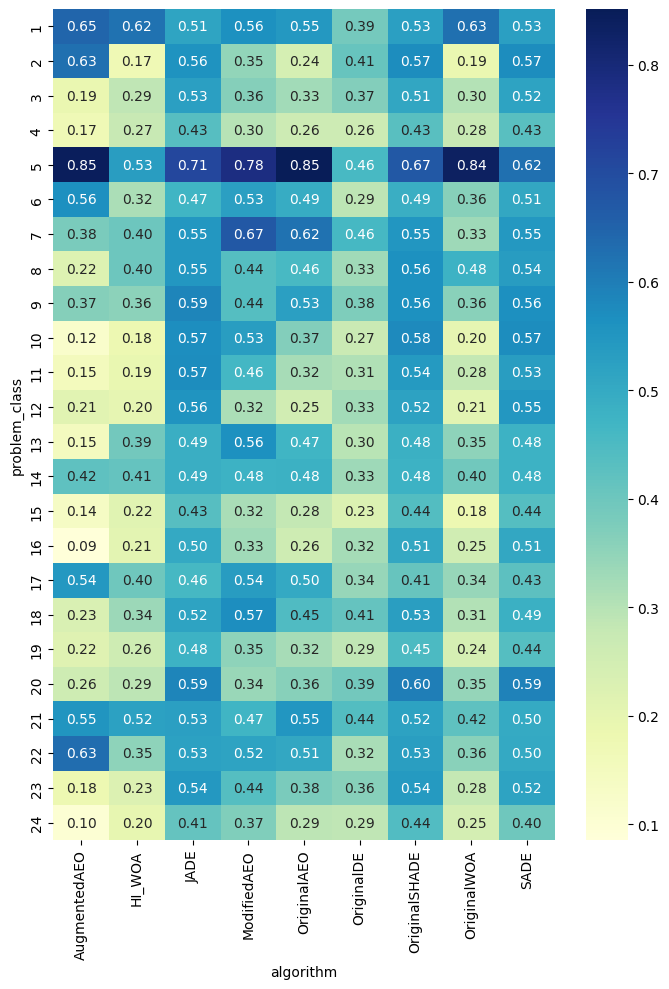

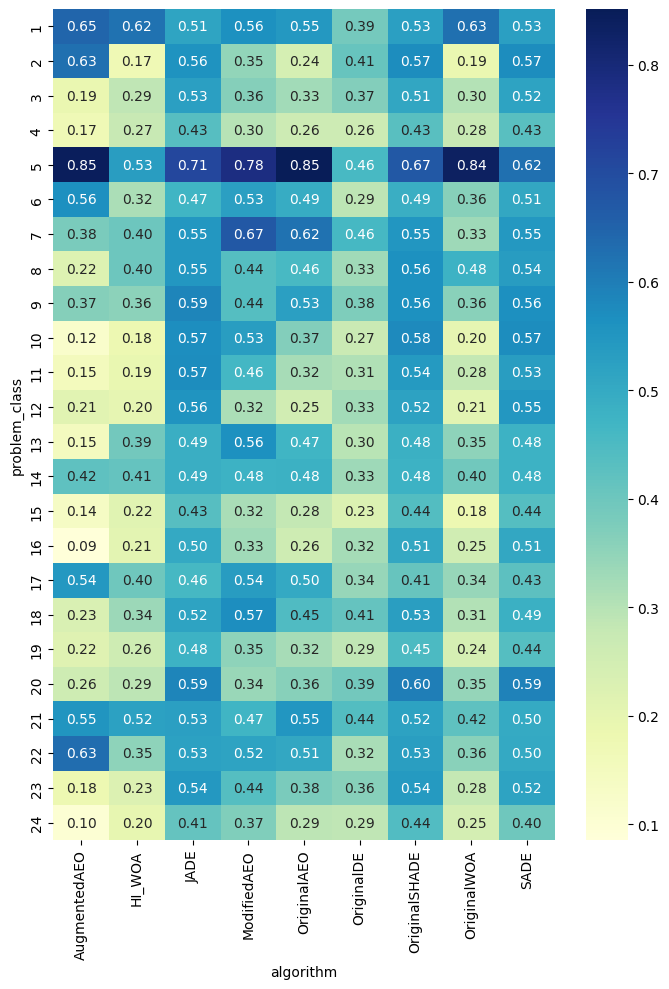

<Figure size 600x600 with 0 Axes>

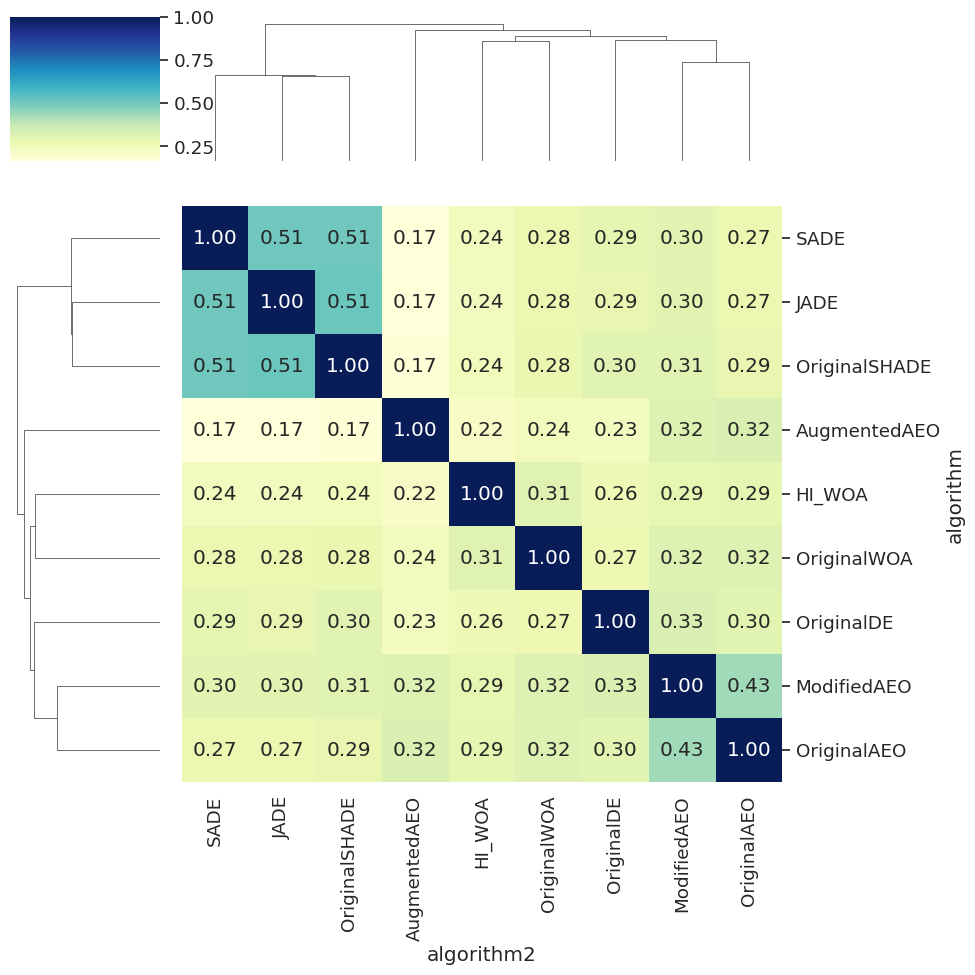

In [13]:
for dimension in [2]:
    directory=f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init/cluster_distributions/dim_{dimension}'
    scale=False
    trajectory_similarities=[]
    for file in tqdm(os.listdir(directory)):
        file_loc=f'{directory}/{file}'
        if os.path.isfile(file_loc):
            df=pd.read_csv(file_loc,index_col=[0,1,2])
            d_algorithm_run=df.unstack(level=-1).dropna()
            d_algorithm_run=pd.DataFrame(MinMaxScaler().fit_transform(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.columns).dropna()
            cs=pd.DataFrame(cosine_similarity(d_algorithm_run), index=d_algorithm_run.index, columns=d_algorithm_run.index)
            c=cs.reset_index().rename(columns={'algorithm':'algorithm2', 'run':'run2'}).melt(id_vars=[('algorithm2',  ''),('run2',  '')], value_vars=list(cs.columns)).rename(columns={('algorithm2',  ''): 'algorithm2', ('run2',''):'run2'})
            trajectory_similarities+=[c.assign(problem=file.replace('.csv',''))]
    
    trajectory_similarities=pd.concat(trajectory_similarities)
    t=trajectory_similarities.groupby('algorithm').count()['run']
    t_max=t.max()
    algorithms_to_remove=list(t[t<t_max].index)
    trajectory_similarities=trajectory_similarities.query('algorithm not in @algorithms_to_remove and algorithm2 not in @algorithms_to_remove')
    trajectory_similarities['problem_class']=[int(tt.split('_')[0].replace('F','')) for tt in trajectory_similarities['problem']]
    trajectory_similarities['instance']=[int(tt.split('_')[1].replace('I','')) for tt in trajectory_similarities['problem']]

    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new/algorithm_similarity_per_problem_dim_{dimension}_scale_{scale}.pdf')


    plt.figure(figsize=(7,10))
    sim_per_problem_algorithm=trajectory_similarities.query('algorithm==algorithm2 and run!=run2').groupby(['problem_class','algorithm'])['value'].mean()
    sns.heatmap(sim_per_problem_algorithm.reset_index().pivot(index='problem_class',columns='algorithm',values='value').sort_index(),annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new/algorithm_stability_per_problem_dim_{dimension}_scale_{scale}.pdf')

    cross_algorithm_similarity=trajectory_similarities.query('run==run2').groupby(['algorithm','algorithm2'])['value'].mean()
    cross_algorithm_similarity_pivoted=cross_algorithm_similarity.reset_index().pivot(index='algorithm',columns='algorithm2',values='value')
    sns.set(font_scale=1.2)
    plt.figure(figsize=(6,6))
    sns.clustermap(cross_algorithm_similarity_pivoted,annot=True,fmt=".2f", cmap='YlGnBu')
    plt.tight_layout()
    plt.savefig(f'figures_clustering_new/algorithm_mean_similarity_clustermap_dim_{dimension}_scale_{scale}.pdf')
    sns.set(font_scale=1)


In [14]:
optimizer_group=get_algorithm_groups()


In [16]:
cross_algorithm_similarity_to_save=cross_algorithm_similarity.reset_index()
cross_algorithm_similarity_to_save['algorithm_group']=cross_algorithm_similarity_to_save['algorithm'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save['algorithm2_group']=cross_algorithm_similarity_to_save['algorithm2'].apply(lambda x: optimizer_group[x])
cross_algorithm_similarity_to_save.sort_values('value',ascending=False).query('algorithm!=algorithm2').to_csv(f'data/clustering_features_x_only_10_algorithms_kmeans_2pow_no_init/algorithm_pairwise_similarity/algorithm_mean_similarity_{dimension}D.csv')

In [17]:

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

unique_optimizer_groups=list(set(optimizer_group.values()))
#optimizer_group={k:str(v).split('.')[1] for k,v in optimizers.items()}
unique_colors=list(sns.color_palette("tab10"))
group_color={f:unique_colors[fi] for fi, f in enumerate(unique_optimizer_groups)}

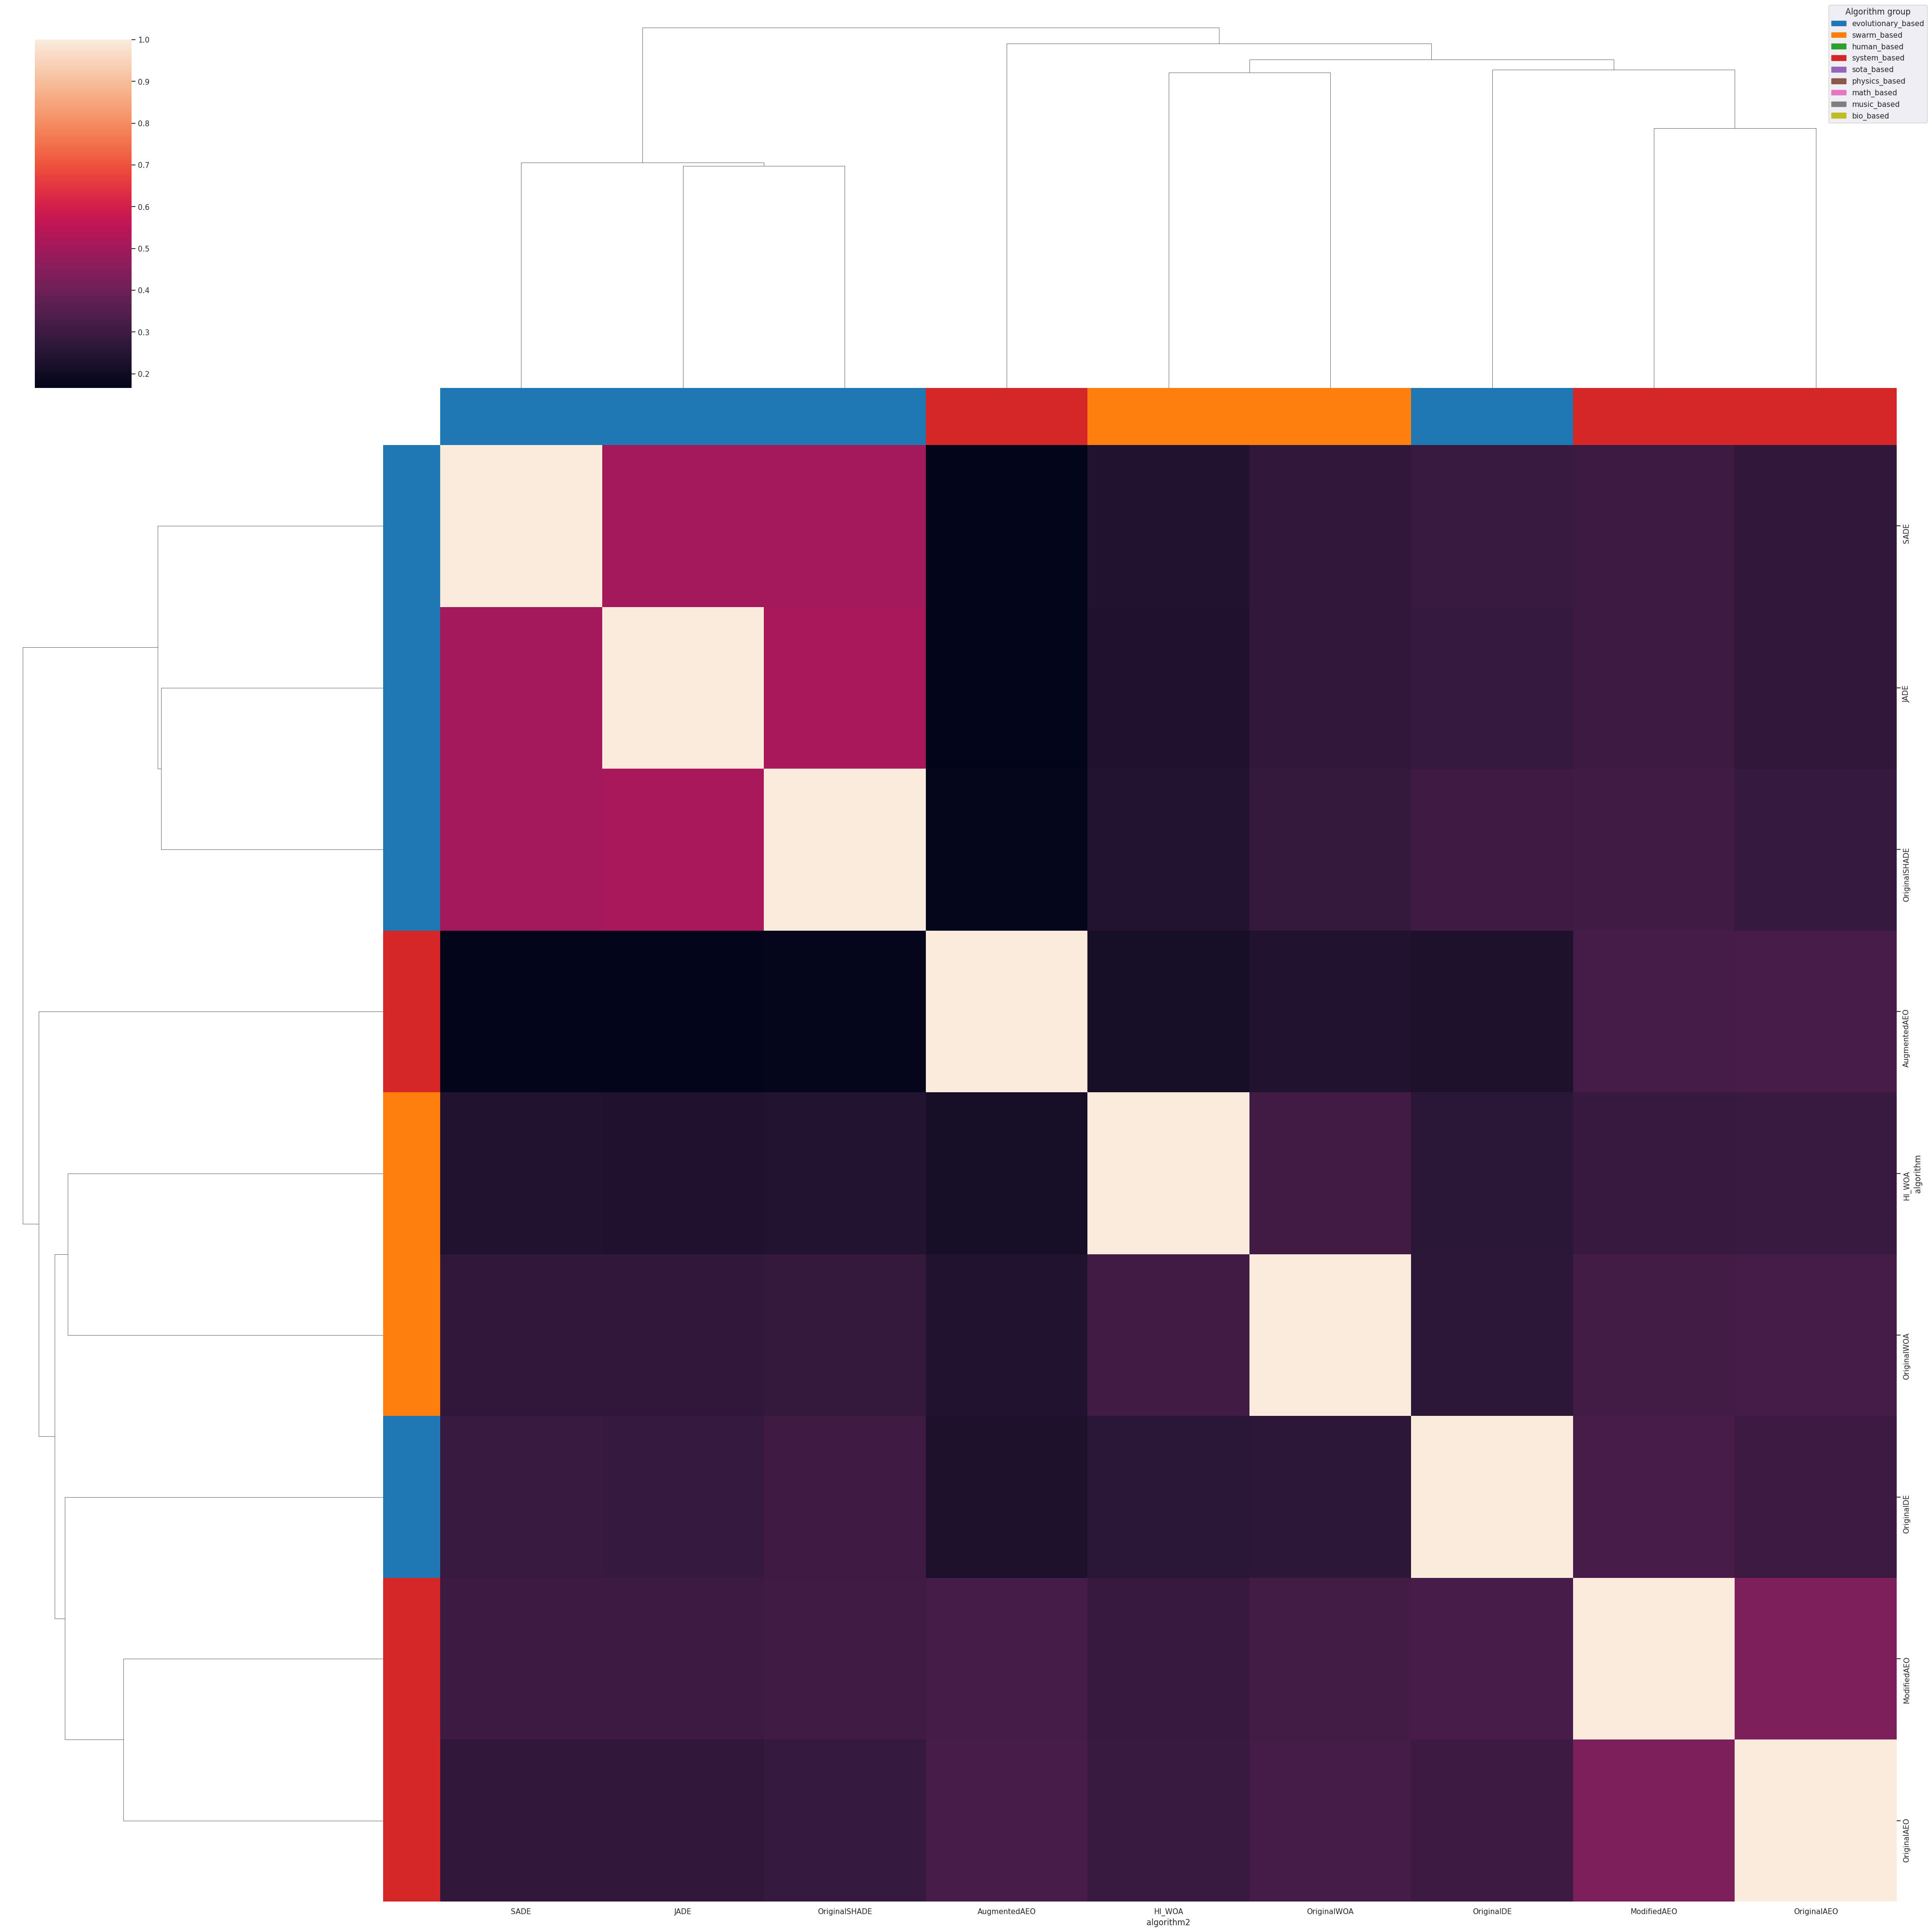

In [19]:
row_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.index]
col_colors=[group_color[optimizer_group[o]] for o in cross_algorithm_similarity_pivoted.columns]
sns.clustermap(cross_algorithm_similarity_pivoted, row_colors=row_colors, col_colors=col_colors,figsize=(40,40))
handles = [mpatches.Patch(color=color, label=label) for label, color in group_color.items()]
# Add legend to the clustermap
plt.legend(handles=handles, title='Algorithm group', bbox_to_anchor=(1, 1), bbox_transform=plt.gcf().transFigure)

plt.savefig(f'figures_clustering/algorithm_mean_similarity_clustermap_dim{dimension}.pdf')
plt.show()
